# ⚙️ Notebook 3: Feature Engineering
## LAFIAKALO Holistic Health ML Model

**Purpose**: Transform raw multi-domain health data into ML-ready feature vectors.

**Input**: Processed CSVs from `data/processed/` (Notebook 01 output)

**Output**: `data/features/health_features.csv` — one row per day, ~150+ features

### Feature Categories
| Category | Features | Description |
|----------|----------|-------------|
| Dialysis | ~25 | Pre/post vitals, UF, blood flow rate, session duration, weight delta |
| Labs | ~30 | BUN, Cr, K, Phos, Ca, Alb, Hgb, Na, CO2 (current + trend + z-score) |
| Nutrition | ~20 | Daily calories, protein, Na, K, Phos, fluid, macro ratios |
| Elimination | ~12 | Bowel frequency, Bristol scale avg, vomit episodes, urine output |
| Medications | ~8 | Active count, changes, polypharmacy index, compliance |
| Mood/Sleep | ~10 | Mood/energy/stress/anxiety scores, sleep hours/quality |
| Mental Health | ~8 | PHQ-9, GAD-7 scores, breathing sessions |
| Vitals | ~10 | BP, HR, weight, BMI, SpO2, temperature |
| Fitness | ~8 | Activity minutes, calories burned, steps, intensity |
| Temporal | ~12 | Day of week, month, days since last dialysis, seasonal indicators |

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FEATURES_DIR = PROJECT_ROOT / 'data' / 'features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

def load_csv(name):
    """Load a processed CSV if it exists, else return empty DataFrame."""
    path = PROCESSED_DIR / f'{name}.csv'
    if path.exists():
        df = pd.read_csv(path, low_memory=False)
        # Parse date columns
        for col in df.columns:
            if col in ('date', 'session_date'):
                df[col] = pd.to_datetime(df[col], errors='coerce')
        return df
    print(f"  ⚠️  {name}.csv not found")
    return pd.DataFrame()

# Load all processed domains (exact names from Notebook 01)
sessions   = load_csv('dialysis_sessions')   # 1,797 sessions
readings   = load_csv('dialysis_readings')   # 15,711 intra-session readings
labs       = load_csv('unified_labs')         # 9,660 lab results
nutrition  = load_csv('unified_nutrition')    # 4,094 food entries
elimination= load_csv('unified_elimination') # 3,844 bowel + vomit entries

# Derive bowel and vomit subsets from unified_elimination (vomit merged in NB01)
bowel = elimination[elimination['type'] == 'bowel'].copy() if 'type' in elimination.columns else elimination.copy()
vomit = elimination[elimination['type'] == 'vomit'].copy() if 'type' in elimination.columns else pd.DataFrame()

meds       = load_csv('medications')          # 953 medication records
vitals     = load_csv('vitals')               # 15 standalone vital readings
mood       = load_csv('journal_mood')         # 5 mood entries
symptoms   = load_csv('symptoms')             # 1 symptom entry

loaded = {k: v for k, v in {
    'dialysis_sessions': sessions, 'dialysis_readings': readings,
    'labs': labs, 'nutrition': nutrition, 'elimination': elimination,
    'medications': meds, 'vitals': vitals,
    'mood': mood, 'symptoms': symptoms
}.items() if not v.empty}

print(f"Loaded {len(loaded)} datasets:")
for name, df in loaded.items():
    print(f"  {name:25s} {len(df):>6,} rows × {df.shape[1]} cols")
if not vomit.empty:
    print(f"  {'  └─ vomit (subset)':25s} {len(vomit):>6,} rows")
    print(f"  {'  └─ bowel (subset)':25s} {len(bowel):>6,} rows")

Loaded 9 datasets:
  dialysis_sessions          1,797 rows × 105 cols
  dialysis_readings         15,711 rows × 14 cols
  labs                       9,660 rows × 18 cols
  nutrition                  4,094 rows × 33 cols
  elimination                3,844 rows × 17 cols
  medications                  953 rows × 13 cols
  vitals                        15 rows × 11 cols
  mood                           5 rows × 6 cols
  symptoms                       1 rows × 7 cols
    └─ vomit (subset)        1,375 rows
    └─ bowel (subset)        2,469 rows


---
## 1. Determine Date Range
Build a daily date index covering the full data span.

In [2]:
# Find global date range across all datasets
all_dates = []
date_col_map = {
    'dialysis_sessions': 'session_date',
    'labs': 'date', 'nutrition': 'date', 'elimination': 'date',
    'medications': 'date', 'vitals': 'date',
    'mood': 'date', 'symptoms': 'date',
}

for name, df in loaded.items():
    dc = date_col_map.get(name)
    if dc and dc in df.columns:
        dates = pd.to_datetime(df[dc], errors='coerce').dropna()
        if not dates.empty:
            all_dates.extend([dates.min(), dates.max()])

date_start = min(all_dates) if all_dates else pd.Timestamp('2016-05-01')
date_end   = max(all_dates) if all_dates else pd.Timestamp.now()

# Create daily index
date_index = pd.date_range(start=date_start.normalize(), end=date_end.normalize(), freq='D')
features = pd.DataFrame(index=date_index)
features.index.name = 'date'

print(f"Feature date range: {date_start.date()} → {date_end.date()}")
print(f"Total days: {len(date_index):,}")

Feature date range: 2016-04-28 → 2026-02-20
Total days: 3,586


---
## 2. Dialysis Features
Extract from FlowSheet Excel and/or therapy_sessions API data.

In [3]:
def extract_dialysis_features(sessions_df, readings_df, date_index):
    """Extract dialysis features from session-level and intra-session reading data."""
    feats = pd.DataFrame(index=date_index)
    
    if sessions_df.empty:
        print("  ⚠️  No dialysis data.")
        return feats
    
    s = sessions_df.copy()
    s['_date'] = pd.to_datetime(s['session_date'], errors='coerce').dt.normalize()
    s = s.dropna(subset=['_date'])
    daily = s.groupby('_date')
    
    # --- Binary: had session today ---
    feats['dial_had_session'] = daily.size().reindex(date_index, fill_value=0).clip(upper=1)
    feats['dial_sessions_count'] = daily.size().reindex(date_index, fill_value=0)
    
    # --- Weight features ---
    num_cols = ['today_weight_kg', 'post_weight_kg', 'weight_loss_kg',
                'pre_weight_kg', 'target_weight_kg']
    for col in num_cols:
        if col in s.columns:
            s[col] = pd.to_numeric(s[col], errors='coerce')
    
    if 'today_weight_kg' in s.columns:
        feats['dial_pre_weight'] = daily['today_weight_kg'].mean().reindex(date_index)
    if 'post_weight_kg' in s.columns:
        feats['dial_post_weight'] = daily['post_weight_kg'].mean().reindex(date_index)
    if 'weight_loss_kg' in s.columns:
        feats['dial_weight_loss_kg'] = daily['weight_loss_kg'].mean().reindex(date_index)
    if 'target_weight_kg' in s.columns:
        feats['dial_target_weight'] = daily['target_weight_kg'].mean().reindex(date_index)
    
    # Weight gain between treatments (pre_weight - post_weight of previous session)
    if 'today_weight_kg' in s.columns and 'post_weight_kg' in s.columns:
        feats['dial_interdialytic_gain'] = feats['dial_pre_weight'] - feats['dial_post_weight'].shift(1)
    
    # --- Blood pressure ---
    bp_pairs = [('pre_bp_sys', 'pre_bp_dia', 'pre'),
                ('post_bp_sys', 'post_bp_dia', 'post')]
    for sys_col, dia_col, prefix in bp_pairs:
        if sys_col in s.columns and dia_col in s.columns:
            s[sys_col] = pd.to_numeric(s[sys_col], errors='coerce')
            s[dia_col] = pd.to_numeric(s[dia_col], errors='coerce')
            feats[f'dial_{prefix}_bp_sys'] = daily[sys_col].mean().reindex(date_index)
            feats[f'dial_{prefix}_bp_dia'] = daily[dia_col].mean().reindex(date_index)
            # Mean Arterial Pressure
            feats[f'dial_{prefix}_map'] = (feats[f'dial_{prefix}_bp_sys'] + 2 * feats[f'dial_{prefix}_bp_dia']) / 3
    
    # BP drop during session
    if 'dial_pre_bp_sys' in feats.columns and 'dial_post_bp_sys' in feats.columns:
        feats['dial_bp_drop_sys'] = feats['dial_pre_bp_sys'] - feats['dial_post_bp_sys']
        feats['dial_bp_drop_dia'] = feats['dial_pre_bp_dia'] - feats['dial_post_bp_dia']
    
    # --- Adequacy metrics ---
    adequacy_cols = ['ktv_actual', 'ktv_spk', 'ktv_ek', 'urr', 'npcr']
    for col in adequacy_cols:
        if col in s.columns:
            s[col] = pd.to_numeric(s[col], errors='coerce')
            feats[f'dial_{col}'] = daily[col].mean().reindex(date_index)
    
    # --- Flow rates ---
    flow_cols = ['avg_blood_flow_rate', 'avg_dialysate_rate']
    for col in flow_cols:
        if col in s.columns:
            s[col] = pd.to_numeric(s[col], errors='coerce')
            feats[f'dial_{col}'] = daily[col].mean().reindex(date_index)
    
    # --- Fluid removal ---
    fluid_cols = ['fluid_to_remove', 'fluid_removed_liters', 'total_uf_kg']
    for col in fluid_cols:
        if col in s.columns:
            s[col] = pd.to_numeric(s[col], errors='coerce')
            feats[f'dial_{col}'] = daily[col].mean().reindex(date_index)
    
    # --- Intra-dialytic BP variability from readings ---
    if not readings_df.empty:
        r = readings_df.copy()
        r['_date'] = pd.to_datetime(r['session_date'], errors='coerce').dt.normalize()
        r = r.dropna(subset=['_date'])
        for col in ['bp_sys', 'bp_dia', 'pulse']:
            r[col] = pd.to_numeric(r[col], errors='coerce')
        
        rdaily = r.groupby('_date')
        feats['dial_intra_bp_sys_std'] = rdaily['bp_sys'].std().reindex(date_index)
        feats['dial_intra_bp_dia_std'] = rdaily['bp_dia'].std().reindex(date_index)
        feats['dial_intra_bp_sys_range'] = (rdaily['bp_sys'].max() - rdaily['bp_sys'].min()).reindex(date_index)
        feats['dial_intra_pulse_mean'] = rdaily['pulse'].mean().reindex(date_index)
        feats['dial_n_readings'] = rdaily.size().reindex(date_index, fill_value=0)
    
    # --- Temporal features ---
    session_dates = s['_date'].dropna().sort_values().unique()
    days_since = pd.Series(np.nan, index=date_index)
    for i, d in enumerate(date_index):
        past = session_dates[session_dates <= d]
        if len(past) > 0:
            days_since.iloc[i] = (d - past[-1]).days
    feats['dial_days_since_last'] = days_since
    
    session_flag = feats['dial_had_session']
    feats['dial_sessions_7d'] = session_flag.rolling(7, min_periods=1).sum()
    feats['dial_sessions_30d'] = session_flag.rolling(30, min_periods=1).sum()
    
    n = feats.notna().any().sum()
    print(f"  ✅ Dialysis: {n} features")
    return feats

dial_feats = extract_dialysis_features(sessions, readings, date_index)
features = features.join(dial_feats)

  ✅ Dialysis: 33 features


---
## 3. Lab Features
For each key lab test: current value, 30/90-day rolling mean, trend slope, z-score.

In [4]:
def extract_lab_features(df_labs, date_index):
    """Extract lab features: current value, rolling mean, trend, z-score per key test."""
    feats = pd.DataFrame(index=date_index)
    
    if df_labs.empty:
        print("  ⚠️  No lab data.")
        return feats
    
    df = df_labs.copy()
    df['_date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    df['value_numeric'] = pd.to_numeric(df['value_numeric'], errors='coerce')
    df = df.dropna(subset=['_date', 'test_name'])
    
    # Key renal/dialysis labs — patterns matched against test_name
    KEY_LABS = {
        # Renal
        'bun':          r'(?i)\bBUN\b|Blood Urea Nitrogen',
        'creatinine':   r'(?i)\bCreatinine\b',
        'potassium':    r'(?i)\bPotassium\b',
        'sodium':       r'(?i)\bSodium\b',
        'phosphorus':   r'(?i)\bPhosphorus\b',
        'calcium':      r'(?i)\bCalcium\b(?!.*Phos)',
        'co2':          r'(?i)\bCO2\b|Bicarbonate',
        'chloride':     r'(?i)\bChloride\b',
        # Anemia / Hematology
        'hemoglobin':   r'(?i)\bHemoglobin\b(?!.*A1c)',
        'hematocrit':   r'(?i)\bHematocrit\b',
        'rbc':          r'(?i)\bRBC\b|Red Blood Cell',
        'wbc':          r'(?i)\bWBC\b|White Blood Cell',
        'platelets':    r'(?i)\bPlatelet\b',
        'mcv':          r'(?i)\bMCV\b',
        'mch':          r'(?i)\bMCH\b(?!C)',
        'mchc':         r'(?i)\bMCHC\b',
        'rdw':          r'(?i)\bRDW\b',
        'reticulocyte': r'(?i)\bReticulocyte\b',
        # Iron
        'ferritin':     r'(?i)\bFerritin\b',
        'iron':         r'(?i)\bIron\b(?!.*Bind)',
        'tibc':         r'(?i)\bTIBC\b|Iron Binding',
        'isat':         r'(?i)\bISAT\b|Iron Sat',
        # Nutrition
        'albumin':      r'(?i)\bAlbumin\b',
        'prealbumin':   r'(?i)\bPrealbumin\b|Transthyretin',
        # Bone / Mineral
        'pth':          r'(?i)\bPTH\b|Parathyroid',
        'vitamin_d':    r'(?i)Vitamin D|25-Hydroxy',
        'alk_phos':     r'(?i)\bALP\b|Alk.*Phos|Alkaline Phosph',
        'ca_x_po4':     r'(?i)CA\*PO|Ca.*x.*P',
        # Hepatic
        'alt':          r'(?i)\bALT\b|Alanine Amino',
        'ast':          r'(?i)\bAST\b|Aspartate Amino',
        'bilirubin':    r'(?i)\bBilirubin\b.*Total',
        # Cardiac / Lipids
        'triglycerides':r'(?i)\bTriglyceride\b',
        'cholesterol':  r'(?i)\bCholesterol\b(?!.*(HDL|LDL))',
        'hdl':          r'(?i)\bHDL\b',
        'ldl':          r'(?i)\bLDL\b',
        # Inflammatory
        'crp':          r'(?i)\bCRP\b|C-Reactive',
        'esr':          r'(?i)\bESR\b|Sed.*Rate',
        # Glycemic
        'glucose':      r'(?i)\bGlucose\b',
        'hba1c':        r'(?i)A1c|HbA1c|Hemoglobin A1c',
        # Thyroid
        'tsh':          r'(?i)\bTSH\b',
        # Hemolysis
        'ldh':          r'(?i)\bLDH\b|Lactate Dehydro',
        'haptoglobin':  r'(?i)\bHaptoglobin\b',
        # Other
        'magnesium':    r'(?i)\bMagnesium\b',
        'uric_acid':    r'(?i)\bUric Acid\b',
    }
    
    for lab_key, pattern in KEY_LABS.items():
        mask = df['test_name'].str.contains(pattern, regex=True, na=False)
        subset = df[mask].copy()
        
        if subset.empty or subset['value_numeric'].notna().sum() < 3:
            continue
        
        # Daily value (latest if multiple per day)
        daily_val = (subset.sort_values('date')
                     .groupby('_date')['value_numeric']
                     .last()
                     .reindex(date_index))
        
        # Forward-fill labs up to 90 days
        filled = daily_val.ffill(limit=90)
        
        feats[f'lab_{lab_key}'] = filled
        feats[f'lab_{lab_key}_30d'] = filled.rolling(30, min_periods=1).mean()
        feats[f'lab_{lab_key}_90d'] = filled.rolling(90, min_periods=1).mean()
        
        # Trend: slope of last 5 actual measurements
        actual = daily_val.dropna()
        if len(actual) > 2:
            trend = actual.rolling(5, min_periods=3).apply(
                lambda x: np.polyfit(range(len(x)), x.values, 1)[0] if len(x) >= 3 else np.nan,
                raw=False
            )
            feats[f'lab_{lab_key}_trend'] = trend.reindex(date_index).ffill(limit=30)
        
        # Z-score from personal baseline
        mean_val = actual.mean()
        std_val = actual.std()
        if std_val > 0:
            feats[f'lab_{lab_key}_zscore'] = (filled - mean_val) / std_val
    
    n = feats.notna().any().sum()
    actual_labs = sum(1 for k in KEY_LABS if f'lab_{k}' in feats.columns)
    print(f"  ✅ Labs: {n} features from {actual_labs}/{len(KEY_LABS)} target tests")
    return feats

lab_feats = extract_lab_features(labs, date_index)
features = features.join(lab_feats)

  ✅ Labs: 185 features from 37/44 target tests


---
## 4. Nutrition Features
Daily totals from Excel Records + API nutrition logs. Focus on renal diet constraints.

In [5]:
def extract_nutrition_features(df_nutr, date_index):
    """Extract daily nutrition features from unified_nutrition."""
    feats = pd.DataFrame(index=date_index)
    
    if df_nutr.empty:
        print("  ⚠️  No nutrition data.")
        return feats
    
    df = df_nutr.copy()
    df['_date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    df = df.dropna(subset=['_date'])
    daily = df.groupby('_date')
    
    # Direct nutrient columns from unified_nutrition
    NUTRIENT_COLS = {
        'nutr_calories':     'calories',
        'nutr_protein_g':    'protein',
        'nutr_carbs_g':      'carbs',
        'nutr_fat_g':        'fat',
        'nutr_fiber_g':      'fiber',
        'nutr_sugar_g':      'sugar',
        'nutr_sodium_mg':    'sodium',
        'nutr_potassium_mg': 'potassium',
        'nutr_calcium_mg':   'calcium',
        'nutr_iron_mg':      'iron',
        'nutr_phosphorus_mg':'phosphorus',
        'nutr_vitamin_d':    'vitamin_d',
        'nutr_vitamin_b12':  'vitamin_b12',
        'nutr_folic_acid':   'folic_acid',
        'nutr_cholesterol':  'cholesterol',
    }
    
    matched = 0
    for feat_name, src_col in NUTRIENT_COLS.items():
        if src_col in df.columns:
            df[src_col] = pd.to_numeric(df[src_col], errors='coerce')
            daily_sum = df.groupby('_date')[src_col].sum().reindex(date_index)
            feats[feat_name] = daily_sum
            feats[f'{feat_name}_7d'] = daily_sum.rolling(7, min_periods=1).mean()
            matched += 1
    
    # Meal count per day
    feats['nutr_meal_count'] = daily.size().reindex(date_index, fill_value=0)
    feats['nutr_logged_today'] = (feats['nutr_meal_count'] > 0).astype(int)
    
    # Macro ratios
    macro_cols = ['nutr_protein_g', 'nutr_carbs_g', 'nutr_fat_g']
    if all(c in feats.columns for c in macro_cols):
        total = feats['nutr_protein_g'] + feats['nutr_carbs_g'] + feats['nutr_fat_g']
        total_safe = total.replace(0, np.nan)
        feats['nutr_protein_ratio'] = feats['nutr_protein_g'] / total_safe
        feats['nutr_carb_ratio'] = feats['nutr_carbs_g'] / total_safe
        feats['nutr_fat_ratio'] = feats['nutr_fat_g'] / total_safe
    
    # Renal diet compliance indicators
    if 'nutr_sodium_mg' in feats.columns:
        feats['nutr_sodium_high'] = (feats['nutr_sodium_mg'] > 2000).astype(int)  # >2g/day
    if 'nutr_potassium_mg' in feats.columns:
        feats['nutr_potassium_high'] = (feats['nutr_potassium_mg'] > 2000).astype(int)
    if 'nutr_phosphorus_mg' in feats.columns:
        feats['nutr_phosphorus_high'] = (feats['nutr_phosphorus_mg'] > 800).astype(int)
    
    # Weight change around meals (pre/post meal weights)
    if 'pre_meal_weight_kg' in df.columns and 'post_meal_weight_kg' in df.columns:
        df['_meal_weight_delta'] = (pd.to_numeric(df['post_meal_weight_kg'], errors='coerce') - 
                                     pd.to_numeric(df['pre_meal_weight_kg'], errors='coerce'))
        feats['nutr_meal_weight_gain'] = df.groupby('_date')['_meal_weight_delta'].mean().reindex(date_index)
    
    n = feats.notna().any().sum()
    print(f"  ✅ Nutrition: {n} features ({matched} nutrient columns matched)")
    return feats

nutr_feats = extract_nutrition_features(nutrition, date_index)
features = features.join(nutr_feats)

  ✅ Nutrition: 39 features (15 nutrient columns matched)


---
## 5. Elimination Features
Bowel movements (Bristol scale, frequency) and vomiting episodes.

In [6]:
def extract_elimination_features(df_elim, df_vomit, date_index):
    """Extract bowel + vomit features from unified_elimination subsets."""
    feats = pd.DataFrame(index=date_index)
    
    # --- Bowel movements ---
    if not df_elim.empty:
        bo = df_elim.copy()
        bo['_date'] = pd.to_datetime(bo['date'], errors='coerce').dt.normalize()
        bo = bo.dropna(subset=['_date'])
        daily = bo.groupby('_date')
        
        feats['elim_bowel_count'] = daily.size().reindex(date_index, fill_value=0)
        feats['elim_bowel_7d_avg'] = feats['elim_bowel_count'].rolling(7, min_periods=1).mean()
        feats['elim_bowel_logged'] = (feats['elim_bowel_count'] > 0).astype(int)
        
        # Blood present
        if 'blood' in bo.columns:
            bo['_blood'] = bo['blood'].apply(
                lambda x: 1 if str(x).lower() in ['true', 'yes', '1', 'present'] else 0
            )
            feats['elim_blood_present'] = bo.groupby('_date')['_blood'].max().reindex(date_index, fill_value=0)
        
        # Weight from bowel events
        if 'pre_weight_kg' in bo.columns and 'post_weight_kg' in bo.columns:
            bo['_elim_weight_loss'] = (pd.to_numeric(bo['pre_weight_kg'], errors='coerce') -
                                        pd.to_numeric(bo['post_weight_kg'], errors='coerce'))
            feats['elim_bowel_weight_loss'] = bo.groupby('_date')['_elim_weight_loss'].sum().reindex(date_index)
    
    # --- Vomiting ---
    if not df_vomit.empty:
        vo = df_vomit.copy()
        vo['_date'] = pd.to_datetime(vo['date'], errors='coerce').dt.normalize()
        vo = vo.dropna(subset=['_date'])
        daily_v = vo.groupby('_date')
        
        feats['elim_vomit_count'] = daily_v.size().reindex(date_index, fill_value=0)
        feats['elim_vomit_7d'] = feats['elim_vomit_count'].rolling(7, min_periods=1).sum()
        feats['elim_vomit_any'] = (feats['elim_vomit_count'] > 0).astype(int)
        
        if 'weight_loss_kg' in vo.columns:
            vo['_vloss'] = pd.to_numeric(vo['weight_loss_kg'], errors='coerce')
            feats['elim_vomit_weight_loss'] = daily_v['_vloss'].sum().reindex(date_index)
    
    # Combined GI health score: bowel regularity good, vomiting bad
    bowel_ok = feats.get('elim_bowel_count', pd.Series(0, index=date_index)).clip(0, 3) / 3
    vomit_bad = feats.get('elim_vomit_count', pd.Series(0, index=date_index)).clip(0, 5) / 5
    feats['elim_gi_health'] = (bowel_ok * 0.7 + (1 - vomit_bad) * 0.3).clip(0, 1)
    
    n = feats.notna().any().sum()
    print(f"  ✅ Elimination: {n} features")
    return feats

elim_feats = extract_elimination_features(bowel, vomit, date_index)
features = features.join(elim_feats)

  ✅ Elimination: 10 features


---
## 6. Medication Features

In [7]:
def extract_medication_features(df_meds, date_index):
    """Extract medication features from medications.csv.
    
    Our meds data has: date, time, medication_name, dosage, source_provider,
    pre/post BP & HR, notes, source.  (No start/end date — each row is a taken dose.)
    """
    feats = pd.DataFrame(index=date_index)
    
    if df_meds.empty:
        print("  ⚠️  No medication data.")
        return feats
    
    m = df_meds.copy()
    m['_date'] = pd.to_datetime(m['date'], errors='coerce').dt.normalize()
    m = m.dropna(subset=['_date'])
    daily = m.groupby('_date')
    
    # Total doses taken per day
    feats['med_doses_today'] = daily.size().reindex(date_index, fill_value=0)
    feats['med_logged'] = (feats['med_doses_today'] > 0).astype(int)
    
    # Unique medications per day
    if 'medication_name' in m.columns:
        feats['med_unique_today'] = daily['medication_name'].nunique().reindex(date_index, fill_value=0)
        
        # One-hot for top medications
        top_meds = m['medication_name'].value_counts().head(10).index
        for med_name in top_meds:
            safe = med_name.lower().replace(' ', '_').replace('(', '').replace(')', '')[:25]
            med_mask = m['medication_name'] == med_name
            med_daily = m[med_mask].groupby('_date').size().reindex(date_index, fill_value=0)
            feats[f'med_{safe}_doses'] = med_daily
    
    # BP at medication time (pre/post) — these capture out-of-dialysis vitals
    bp_cols = [('pre_bp_systolic', 'med_bp_pre_sys'), ('pre_bp_diastolic', 'med_bp_pre_dia'),
               ('post_bp_systolic', 'med_bp_post_sys'), ('post_bp_diastolic', 'med_bp_post_dia'),
               ('pre_heart_rate', 'med_hr_pre'), ('post_heart_rate', 'med_hr_post')]
    for src, feat in bp_cols:
        if src in m.columns:
            m[src] = pd.to_numeric(m[src], errors='coerce')
            feats[feat] = m.groupby('_date')[src].mean().reindex(date_index)
    
    # Rolling adherence: days with meds in last 7/30 days
    feats['med_adherence_7d'] = feats['med_logged'].rolling(7, min_periods=1).mean()
    feats['med_adherence_30d'] = feats['med_logged'].rolling(30, min_periods=1).mean()
    
    n = feats.notna().any().sum()
    print(f"  ✅ Medications: {n} features")
    return feats

med_feats = extract_medication_features(meds, date_index)
features = features.join(med_feats)

  ✅ Medications: 18 features


---
## 7. Mood, Sleep & Mental Health Features

In [8]:
def extract_mood_features(df_mood, df_symptoms, date_index):
    """Extract mood/sleep/symptom features.
    
    journal_mood cols: date, mood, hours_slept, feelings, nutrition_notes, activities
    symptoms cols:     date, symptom, severity, duration_minutes, triggers, relief_measures, notes
    """
    feats = pd.DataFrame(index=date_index)
    
    # --- Mood / Sleep ---
    if not df_mood.empty:
        mo = df_mood.copy()
        mo['_date'] = pd.to_datetime(mo['date'], errors='coerce').dt.normalize()
        mo = mo.dropna(subset=['_date'])
        daily = mo.groupby('_date')
        
        # Mood score (1-10 or text — try numeric first)
        if 'mood' in mo.columns:
            mo['_mood_num'] = pd.to_numeric(mo['mood'], errors='coerce')
            feats['mood_score'] = daily['_mood_num'].mean().reindex(date_index)
            feats['mood_score_7d'] = feats['mood_score'].ffill(limit=7).rolling(7, min_periods=1).mean()
        
        if 'hours_slept' in mo.columns:
            mo['_sleep'] = pd.to_numeric(mo['hours_slept'], errors='coerce')
            feats['mood_sleep_hours'] = daily['_sleep'].mean().reindex(date_index)
            feats['mood_sleep_7d'] = feats['mood_sleep_hours'].ffill(limit=7).rolling(7, min_periods=1).mean()
        
        # Text features from feelings/notes
        text_cols = [c for c in ['feelings', 'nutrition_notes', 'activities'] if c in mo.columns]
        if text_cols:
            mo['_text'] = mo[text_cols].fillna('').agg(' '.join, axis=1).str.lower()
            
            POS = ['good', 'great', 'better', 'happy', 'well', 'comfortable', 'relief', 'improved']
            NEG = ['pain', 'bad', 'worse', 'tired', 'nausea', 'dizzy', 'cramp', 'weak', 'sick', 'vomit']
            
            mo['_pos'] = mo['_text'].apply(lambda t: sum(1 for w in POS if w in str(t)))
            mo['_neg'] = mo['_text'].apply(lambda t: sum(1 for w in NEG if w in str(t)))
            feats['mood_pos_words'] = mo.groupby('_date')['_pos'].sum().reindex(date_index, fill_value=0)
            feats['mood_neg_words'] = mo.groupby('_date')['_neg'].sum().reindex(date_index, fill_value=0)
        
        feats['mood_logged'] = daily.size().reindex(date_index, fill_value=0).clip(upper=1)
    
    # --- Symptoms ---
    if not df_symptoms.empty:
        sy = df_symptoms.copy()
        sy['_date'] = pd.to_datetime(sy['date'], errors='coerce').dt.normalize()
        sy = sy.dropna(subset=['_date'])
        daily_s = sy.groupby('_date')
        
        feats['symptom_count'] = daily_s.size().reindex(date_index, fill_value=0)
        
        if 'severity' in sy.columns:
            sy['_sev'] = pd.to_numeric(sy['severity'], errors='coerce')
            feats['symptom_severity_avg'] = daily_s['_sev'].mean().reindex(date_index)
        
        if 'duration_minutes' in sy.columns:
            sy['_dur'] = pd.to_numeric(sy['duration_minutes'], errors='coerce')
            feats['symptom_duration_total'] = daily_s['_dur'].sum().reindex(date_index)
    
    n = feats.notna().any().sum()
    print(f"  ✅ Mood/Symptoms: {n} features")
    return feats

mood_feats = extract_mood_features(mood, symptoms, date_index)
features = features.join(mood_feats)

  ✅ Mood/Symptoms: 8 features


---
## 8. Vitals Features
Standalone vitals (sparse) + medication-time BP/HR readings as supplementary data.

In [9]:
def extract_vitals_features(df_vitals, df_meds, date_index):
    """Extract standalone vital sign features.
    
    vitals.csv cols: date, bp_systolic, bp_diastolic, heart_rate, body_temperature,
                     temperature_unit, weight, weight_unit, blood_oxygen, blood_glucose, notes
    
    Also use medication BP readings as supplementary vitals (out-of-dialysis).
    """
    feats = pd.DataFrame(index=date_index)
    
    # --- Standalone vitals (sparse: only 15 rows) ---
    if not df_vitals.empty:
        v = df_vitals.copy()
        v['_date'] = pd.to_datetime(v['date'], errors='coerce').dt.normalize()
        v = v.dropna(subset=['_date'])
        
        col_map = {
            'bp_systolic': 'vitals_bp_sys', 'bp_diastolic': 'vitals_bp_dia',
            'heart_rate': 'vitals_hr', 'weight': 'vitals_weight',
            'blood_oxygen': 'vitals_spo2', 'blood_glucose': 'vitals_glucose',
            'body_temperature': 'vitals_temp',
        }
        
        daily = v.groupby('_date')
        for src, feat in col_map.items():
            if src in v.columns:
                v[src] = pd.to_numeric(v[src], errors='coerce')
                feats[feat] = v.groupby('_date')[src].mean().reindex(date_index)
    
    # --- Supplement from medication BP readings (much more data) ---
    if not df_meds.empty and 'pre_bp_systolic' in df_meds.columns:
        m = df_meds.copy()
        m['_date'] = pd.to_datetime(m['date'], errors='coerce').dt.normalize()
        m = m.dropna(subset=['_date'])
        
        for src, feat in [('pre_bp_systolic', 'vitals_med_bp_sys'), 
                          ('pre_bp_diastolic', 'vitals_med_bp_dia'),
                          ('pre_heart_rate', 'vitals_med_hr')]:
            if src in m.columns:
                m[src] = pd.to_numeric(m[src], errors='coerce')
                feats[feat] = m.groupby('_date')[src].mean().reindex(date_index)
    
    # Carry forward vitals (change slowly)
    for col in feats.columns:
        feats[col] = feats[col].ffill(limit=30)
    
    # Rolling averages
    for col in [c for c in feats.columns if not c.endswith('_7d')]:
        feats[f'{col}_7d'] = feats[col].rolling(7, min_periods=1).mean()
    
    # BP derived
    bp_sys = feats.get('vitals_bp_sys', feats.get('vitals_med_bp_sys'))
    bp_dia = feats.get('vitals_bp_dia', feats.get('vitals_med_bp_dia'))
    if bp_sys is not None and bp_dia is not None:
        feats['vitals_map'] = (bp_sys + 2 * bp_dia) / 3
        feats['vitals_pulse_pressure'] = bp_sys - bp_dia
    
    n = feats.notna().any().sum()
    print(f"  ✅ Vitals: {n} features")
    return feats

vitals_feats = extract_vitals_features(vitals, meds, date_index)
features = features.join(vitals_feats)

  ✅ Vitals: 18 features


---
## 9. Activity Proxies
No standalone fitness data — derive activity indicators from dialysis schedule.

In [10]:
# No standalone fitness tracking data exists for this patient.
# Dialysis sessions ARE the primary physical activity (3-4 hrs, 5x/week).
# We can derive activity proxies from dialysis frequency.

feats_activity = pd.DataFrame(index=date_index)

if 'dial_had_session' in features.columns:
    feats_activity['activity_dial_sessions_7d'] = features['dial_sessions_7d']
    feats_activity['activity_active_days_7d'] = features['dial_had_session'].rolling(7, min_periods=1).sum()
    feats_activity['activity_rest_days_streak'] = (
        features['dial_had_session'].eq(0)
        .groupby(features['dial_had_session'].ne(0).cumsum())
        .cumsum()
    )

features = features.join(feats_activity)
print(f"  ✅ Activity proxies: {feats_activity.shape[1]} features (from dialysis schedule)")

  ✅ Activity proxies: 3 features (from dialysis schedule)


---
## 10. Temporal / Calendar Features
Date-based features: day of week, month, season, patient age, dialysis vintage.

In [11]:
# Temporal / calendar features
features['temp_day_of_week'] = features.index.dayofweek
features['temp_is_weekend'] = (features.index.dayofweek >= 5).astype(int)
features['temp_month'] = features.index.month
features['temp_quarter'] = features.index.quarter
features['temp_day_of_year'] = features.index.dayofyear

# Cyclical encoding
features['temp_month_sin'] = np.sin(2 * np.pi * features.index.month / 12)
features['temp_month_cos'] = np.cos(2 * np.pi * features.index.month / 12)
features['temp_dow_sin'] = np.sin(2 * np.pi * features.index.dayofweek / 7)
features['temp_dow_cos'] = np.cos(2 * np.pi * features.index.dayofweek / 7)

# Linear time
features['temp_days_from_start'] = (features.index - features.index[0]).days
features['temp_year'] = features.index.year

# Patient age at each date (DOB: REDACTED)
dob = pd.Timestamp('1900-01-01')  # REDACTED
features['temp_age_years'] = (features.index - dob).days / 365.25

# Dialysis vintage (years on dialysis — start approx 2016-04-28)
dial_start = pd.Timestamp('2016-04-28')
features['temp_dial_vintage_years'] = np.maximum(0, (features.index - dial_start).days / 365.25)

print(f"  ✅ Temporal: 14 features")

  ✅ Temporal: 14 features


---
## 11. Risk Classifiers
Binary (0/1) clinical risk labels derived from lab & dialysis thresholds — 12 targets for multi-label classification.

In [12]:
"""
12 Clinical Risk Classifiers — binary (0/1) labels derived from lab thresholds.
These become targets for downstream multi-label classification in Notebook 04.
"""

RISK_DEFS = {
    # Renal
    'risk_hyperkalemia':    ('lab_potassium',   lambda v: v > 5.5),
    'risk_hypokalemia':     ('lab_potassium',   lambda v: v < 3.5),
    'risk_hyperphosphatemia':('lab_phosphorus',  lambda v: v > 5.5),
    'risk_metabolic_acidosis':('lab_co2',        lambda v: v < 22),
    
    # Anemia / Hematology
    'risk_anemia':          ('lab_hemoglobin',   lambda v: v < 10.0),
    'risk_iron_deficiency': ('lab_ferritin',     lambda v: v < 200),
    
    # Nutrition
    'risk_malnutrition':    ('lab_albumin',      lambda v: v < 3.5),
    
    # Bone / Mineral
    'risk_hyperparathyroid':('lab_pth',          lambda v: v > 600),   # 2-9x upper for ESRD
    'risk_hypocalcemia':    ('lab_calcium',      lambda v: v < 8.4),
    
    # Hepatic
    'risk_liver_stress':    ('lab_alt',          lambda v: v > 56),
    
    # Inflammatory
    'risk_inflammation':    ('lab_crp',          lambda v: v > 3.0),
    
    # Dialysis Adequacy
    'risk_inadequate_dial': ('dial_ktv_actual',  lambda v: v < 1.2),
}

risk_count = 0
for risk_name, (feat_col, threshold_fn) in RISK_DEFS.items():
    if feat_col in features.columns:
        mask = features[feat_col].notna()
        features.loc[mask, risk_name] = features.loc[mask, feat_col].apply(
            lambda v: int(threshold_fn(v)) if pd.notna(v) else np.nan
        )
        positives = features[risk_name].sum()
        total = features[risk_name].notna().sum()
        pct = positives / total * 100 if total > 0 else 0
        print(f"  {risk_name:30s}  {int(positives):>5} / {total:>5} days positive ({pct:.1f}%)")
        risk_count += 1
    else:
        print(f"  {risk_name:30s}  ⚠️  source '{feat_col}' not available")

print(f"\n  ✅ Risk classifiers: {risk_count} created")

  risk_hyperkalemia                 364 /  3395 days positive (10.7%)
  risk_hypokalemia                  422 /  3395 days positive (12.4%)
  risk_hyperphosphatemia              0 /   192 days positive (0.0%)
  risk_metabolic_acidosis           313 /  3539 days positive (8.8%)
  risk_anemia                      1816 /  3417 days positive (53.1%)
  risk_iron_deficiency              717 /  3386 days positive (21.2%)
  risk_malnutrition                 124 /  3395 days positive (3.7%)
  risk_hyperparathyroid            3001 /  3552 days positive (84.5%)
  risk_hypocalcemia                 259 /  3304 days positive (7.8%)
  risk_liver_stress                   0 /  1360 days positive (0.0%)
  risk_inflammation               ⚠️  source 'lab_crp' not available
  risk_inadequate_dial                4 /    21 days positive (19.0%)

  ✅ Risk classifiers: 11 created


---
## 12. Feature Summary & Selection
Drop rows with zero non-temporal data. Show coverage statistics.

In [13]:
# Drop rows with zero data (all NaN except temporal)
temporal_cols = [c for c in features.columns if c.startswith('temp_')]
risk_cols = [c for c in features.columns if c.startswith('risk_')]
non_meta = [c for c in features.columns if not c.startswith('temp_') and not c.startswith('risk_')]
has_data = features[non_meta].notna().any(axis=1)

features_clean = features[has_data].copy()

print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)
print(f"\n  Total features:       {features_clean.shape[1]}")
print(f"  Days with data:       {len(features_clean):,}")
print(f"  Date range:           {features_clean.index.min().date()} → {features_clean.index.max().date()}")

# Feature categories
categories = {}
for col in features_clean.columns:
    prefix = col.split('_')[0]
    categories.setdefault(prefix, []).append(col)

print(f"\n  Features by category:")
for cat in ['dial', 'lab', 'nutr', 'elim', 'med', 'mood', 'symptom', 'vitals', 'activity', 'temp', 'risk']:
    cols = categories.get(cat, [])
    if cols:
        coverage = features_clean[cols].notna().any(axis=0).sum()
        print(f"    {cat:15s}  {len(cols):3d} features  ({coverage} with data)")

# Data density
density = features_clean.notna().mean()
print(f"\n  Feature fill rates:")
print(f"    Average:               {density.mean():.1%}")
print(f"    Features > 50% filled: {(density > 0.5).sum()}")
print(f"    Features > 10% filled: {(density > 0.1).sum()}")
print(f"    Features < 1% filled:  {(density < 0.01).sum()}")

# Risk label summary
if risk_cols:
    print(f"\n  Risk labels ({len(risk_cols)}):")
    for rc in sorted(risk_cols):
        pos = features_clean[rc].sum()
        tot = features_clean[rc].notna().sum()
        if tot > 0:
            print(f"    {rc:32s}  {int(pos):>5} positive / {tot:>5} total ({pos/tot*100:.1f}%)")

FEATURE ENGINEERING SUMMARY

  Total features:       347
  Days with data:       3,586
  Date range:           2016-04-28 → 2026-02-20

  Features by category:
    dial              33 features  (33 with data)
    lab              185 features  (185 with data)
    nutr              39 features  (39 with data)
    elim              10 features  (10 with data)
    med               21 features  (18 with data)
    mood               7 features  (5 with data)
    symptom            3 features  (3 with data)
    vitals            22 features  (18 with data)
    activity           3 features  (3 with data)
    temp              13 features  (13 with data)
    risk              11 features  (11 with data)

  Feature fill rates:
    Average:               65.2%
    Features > 50% filled: 234
    Features > 10% filled: 286
    Features < 1% filled:  23

  Risk labels (11):
    risk_anemia                        1816 positive /  3417 total (53.1%)
    risk_hyperkalemia                   364 posi

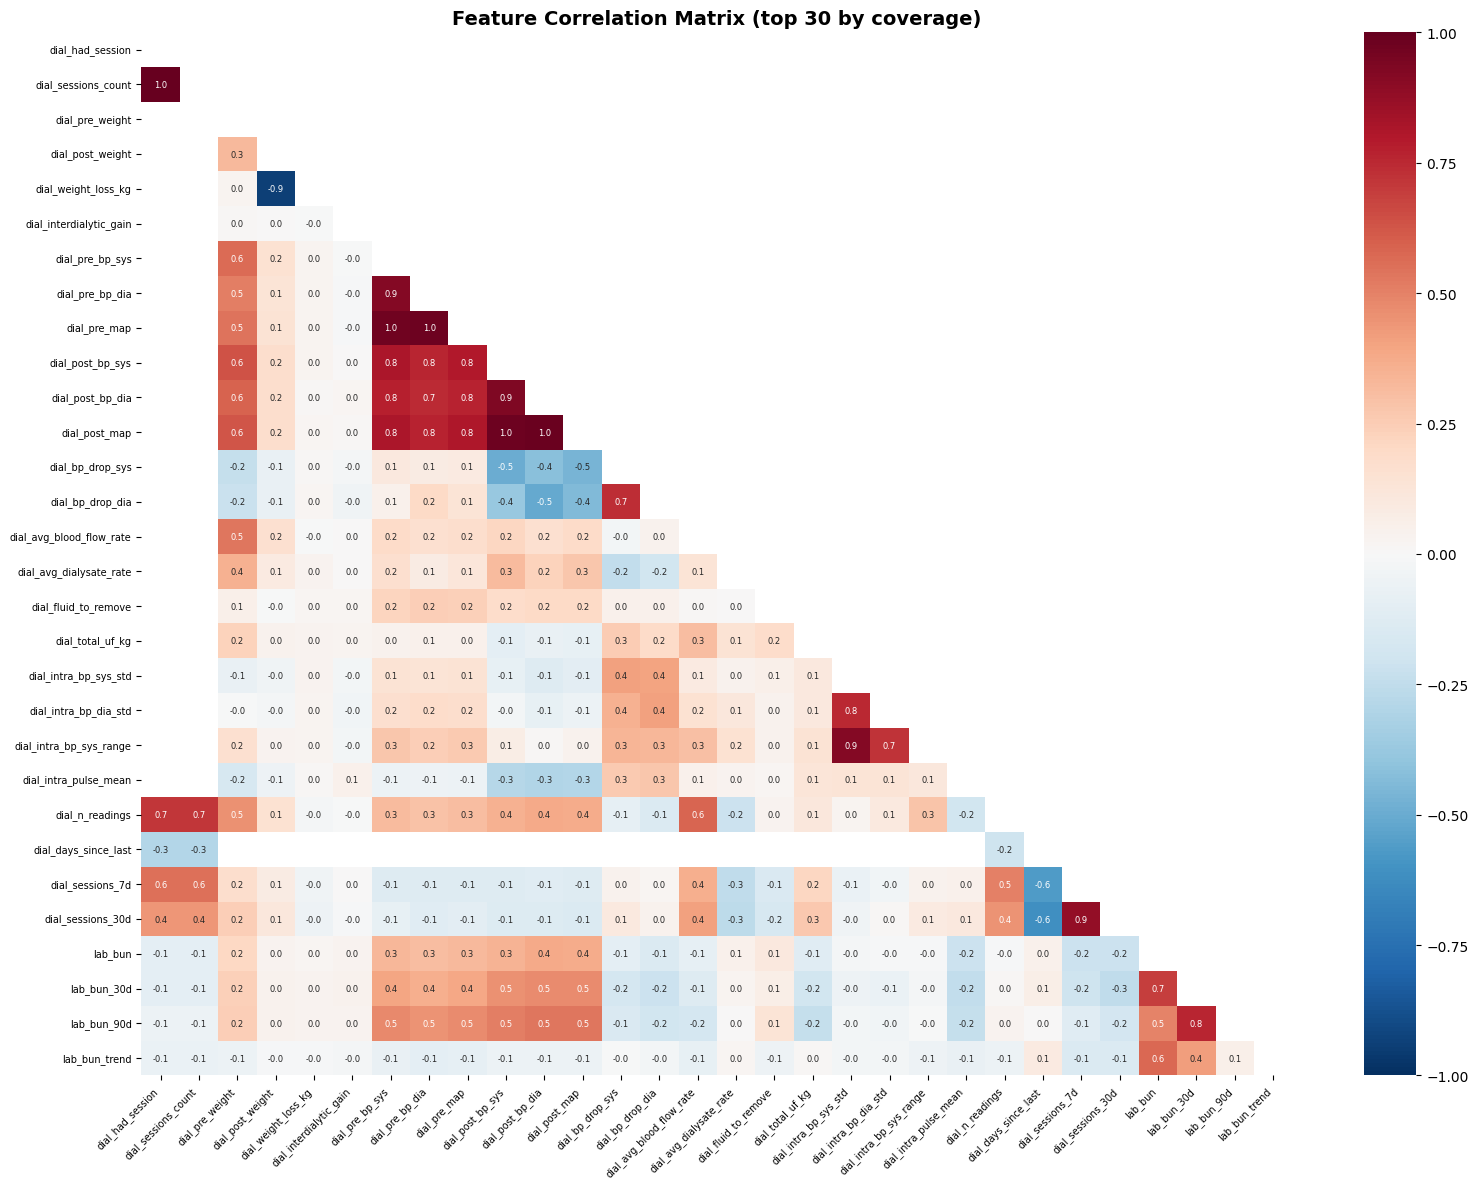

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature correlation heatmap — top features by coverage
density = features_clean.notna().mean()
top_feats = density[(density > 0.1)].index.tolist()
top_feats = [f for f in top_feats if not f.startswith('temp_') and not f.startswith('risk_')][:30]

if len(top_feats) > 3:
    corr = features_clean[top_feats].corr()
    
    fig, ax = plt.subplots(figsize=(16, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.1f', ax=ax, annot_kws={'size': 6})
    ax.set_title('Feature Correlation Matrix (top 30 by coverage)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("  Not enough features with >10% coverage for correlation plot.")

In [15]:
# Save feature matrix
output_path = FEATURES_DIR / 'health_features.csv'
features_clean.to_csv(output_path)

# Save feature metadata
meta = pd.DataFrame({
    'feature': features_clean.columns,
    'dtype': features_clean.dtypes.astype(str).values,
    'coverage': features_clean.notna().mean().values,
    'mean': features_clean.mean(numeric_only=True).reindex(features_clean.columns).values,
    'std': features_clean.std(numeric_only=True).reindex(features_clean.columns).values,
    'min': features_clean.min(numeric_only=True).reindex(features_clean.columns).values,
    'max': features_clean.max(numeric_only=True).reindex(features_clean.columns).values,
})
meta.to_csv(FEATURES_DIR / 'feature_metadata.csv', index=False)

# Save risk labels separately for easy access
risk_cols = [c for c in features_clean.columns if c.startswith('risk_')]
if risk_cols:
    features_clean[risk_cols].to_csv(FEATURES_DIR / 'risk_labels.csv')
    print(f"  {FEATURES_DIR / 'risk_labels.csv'}")

print(f"\n✅ Saved:")
print(f"  {output_path}  ({features_clean.shape[0]:,} × {features_clean.shape[1]})")
print(f"  {FEATURES_DIR / 'feature_metadata.csv'}")
print(f"\n→ Next: Run 04_model_training.ipynb")

  /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/features/risk_labels.csv

✅ Saved:
  /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/features/health_features.csv  (3,586 × 347)
  /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/features/feature_metadata.csv

→ Next: Run 04_model_training.ipynb
